In [1]:
import itertools
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from tensorflow import keras

import numpy as np

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

### Tâche 1 : Chargement et Exploration
1. Chargez CIFAR-10 depuis `keras.datasets.cifar10`
2. Visualisez 20 images aléatoires avec labels
3. Analysez les dimensions et range de pixels
4. Calculez la distribution de classes
5. Normalisez les pixels dans [0, 1]

Attendus : Dataset exploré et normalisé

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

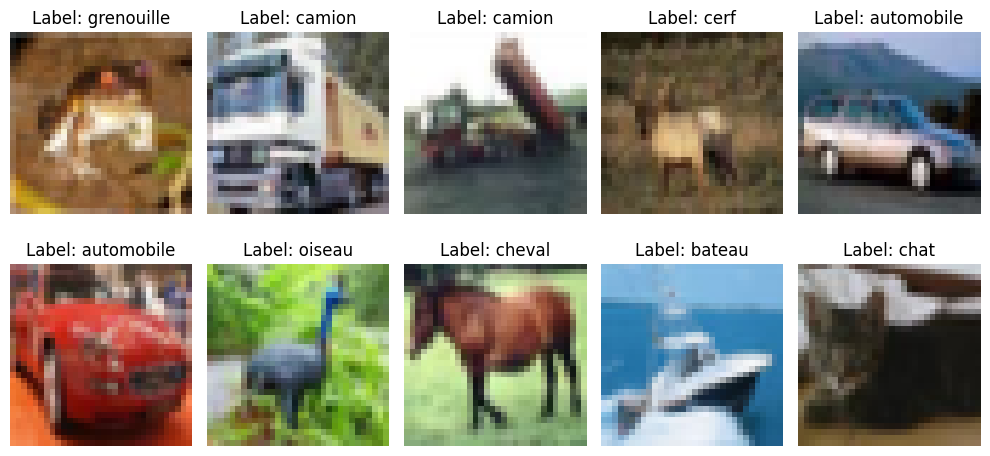

In [ ]:
labels = [
    "avion",
    "automobile",
    "oiseau",
    "chat",
    "cerf",
    "chien",
    "grenouille",
    "cheval",
    "bateau",
    "camion",
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {labels[int(y_train[i])]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_min = X_train.min(axis=(0, 1, 2))
train_max = X_train.max(axis=(0, 1, 2))

test_min = X_test.min(axis=(0, 1, 2))
test_max = X_test.max(axis=(0, 1, 2))

print("Train set:")
print(f"  R: [{train_min[0]}, {train_max[0]}]")
print(f"  G: [{train_min[1]}, {train_max[1]}]")
print(f"  B: [{train_min[2]}, {train_max[2]}]")

print("\nTest set:")
print(f"  R: [{test_min[0]}, {test_max[0]}]")
print(f"  G: [{test_min[1]}, {test_max[1]}]")
print(f"  B: [{test_min[2]}, {test_max[2]}]")

Train set:
  R: [0, 255]
  G: [0, 255]
  B: [0, 255]

Test set:
  R: [0, 255]
  G: [0, 255]
  B: [0, 255]


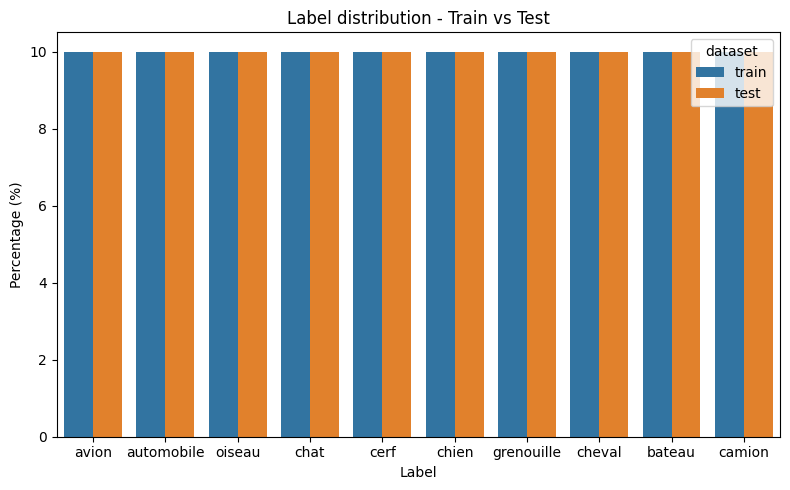

In [ ]:
counter_train = Counter(y_train.ravel())
counter_test = Counter(y_test.ravel())

labels_int = range(len(labels))

df = pd.DataFrame(
    {
        "label": labels * 2,
        "percentage": (
            [counter_train.get(l, 0) / len(y_train) * 100 for l in labels_int]
            + [counter_test.get(l, 0) / len(y_test) * 100 for l in labels_int]
        ),
        "dataset": ["train"] * len(labels) + ["test"] * len(labels),
    }
)

plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="label", y="percentage", hue="dataset")

plt.ylabel("Percentage (%)")
plt.xlabel("Label")

plt.title("Label distribution - Train vs Test")

plt.tight_layout()
plt.show()

In [ ]:
# Normalization: Divide pixels values by 255
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

train_norm_min = X_train_norm.min(axis=(0, 1, 2))
train_norm_max = X_train_norm.max(axis=(0, 1, 2))

test_norm_min = X_test_norm.min(axis=(0, 1, 2))
test_norm_max = X_test_norm.max(axis=(0, 1, 2))

print("Train set normalize:")
print(f"  R: [{train_norm_min[0]}, {train_norm_max[0]}]")
print(f"  G: [{train_norm_min[1]}, {train_norm_max[1]}]")
print(f"  B: [{train_norm_min[2]}, {train_norm_max[2]}]")

print("\nTest set normalize:")
print(f"  R: [{test_norm_min[0]}, {test_norm_max[0]}]")
print(f"  G: [{test_norm_min[1]}, {test_norm_max[1]}]")
print(f"  B: [{test_norm_min[2]}, {test_norm_max[2]}]")

# Encode labels: 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)
print("\nLabels encoded:")
for label in np.unique(y_train):
    idx = np.where(y_train == label)[0][0]
    print(f"{label} ---> {y_train_onehot[idx]}")

Train set normalize:
  R: [0.0, 1.0]
  G: [0.0, 1.0]
  B: [0.0, 1.0]

Test set normalize:
  R: [0.0, 1.0]
  G: [0.0, 1.0]
  B: [0.0, 1.0]

Labels encoded:
0 ---> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1 ---> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
2 ---> [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
3 ---> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
4 ---> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
5 ---> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
6 ---> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
7 ---> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
8 ---> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
9 ---> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


### Tâche 2 : Architecture CNN Simple
1. Construisez un CNN :
   - Conv2D(32, 3x3, relu) + MaxPooling2D(2x2)
   - Conv2D(64, 3x3, relu) + MaxPooling2D(2x2)
   - Flatten
   - Dense(128, relu) + Dropout(0.3)
   - Dense(10, softmax)
2. Compilez avec Adam et categorical_crossentropy
3. Entraînez 15 epochs sans data augmentation

Attendus : Modèle entraîné, accuracy noté

In [ ]:
def create_model() -> keras.Sequential:
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(32, 32, 3), name="input"),
            keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
            keras.layers.MaxPooling2D((2, 2), name="pool1"),
            keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
            keras.layers.MaxPooling2D((2, 2), name="pool2"),
            keras.layers.Flatten(name="flatten"),
            keras.layers.Dense(128, activation="relu", name="dense1"),
            keras.layers.Dense(10, activation="softmax", name="output"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr():
    return keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train_norm,
    y_train_onehot,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4289 - loss: 1.8275 - val_accuracy: 0.5362 - val_loss: 1.2928 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5784 - loss: 1.1878 - val_accuracy: 0.5864 - val_loss: 1.2015 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6493 - loss: 0.9997 - val_accuracy: 0.6095 - val_loss: 1.1626 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6916 - loss: 0.8810 - val_accuracy: 0.6079 - val_loss: 1.1963 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7135 - loss: 0.8128 - val_accuracy: 0.5965 - val_loss: 1.3050 - learning_rate: 0.0010
Epoch 6/20
617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7380 - loss: 0.7447
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7460 - loss: 0.7233 - v

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_onehot, verbose=1)

print(f"\nTest loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7153 - loss: 0.8376

Test loss: 0.8376417756080627
Test accuracy: 0.7153000235557556


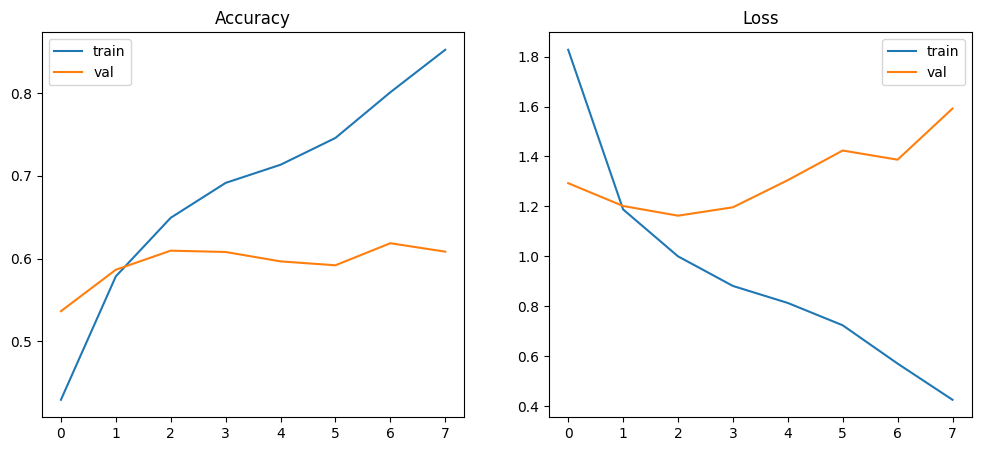

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")

plt.title("Loss")
plt.legend()

plt.show()

### Tâche 3 : Data Augmentation
1. Implémentez ImageDataGenerator avec :
   - Rotation : 20 degrés
   - Width/height shift : 0.2
   - Horizontal flip
   - Zoom : 0.2
2. Entraînez le même CNN avec augmentation
3. Comparez les courbes avec/sans augmentation
4. Analysez l'impact sur train/val accuracy

Attendus : Comparaison quantifiée, visualisations

In [ ]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,
)

train_generator = train_datagen.flow(
    X_train_norm,
    y_train_onehot,
    batch_size=64,
    subset="training",
)

val_datagen = keras.preprocessing.image.ImageDataGenerator(validation_split=0.2)

val_generator = val_datagen.flow(
    X_train_norm,
    y_train_onehot,
    batch_size=64,
    subset="validation",
)

In [ ]:
history_aug = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5646 - loss: 1.2421 - val_accuracy: 0.6282 - val_loss: 1.0599 - learning_rate: 5.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5702 - loss: 1.2159 - val_accuracy: 0.6674 - val_loss: 0.9583 - learning_rate: 5.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.5808 - loss: 1.1890 - val_accuracy: 0.6516 - val_loss: 1.0073 - learning_rate: 5.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.5918 - loss: 1.1629 - val_accuracy: 0.6450 - val_loss: 1.0562 - learning_rate: 5.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5952 - loss: 1.1531
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.5968 - loss: 1.1554 - val_accuracy: 0.6562 - val_loss: 0.9913 - learning_rate: 5.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - ac

In [ ]:
test_loss_aug, test_accuracy_aug = model.evaluate(X_test_norm, y_test_onehot, verbose=1)

print(f"\nTest loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

print(f"\nTest loss aug: {test_loss_aug}")
print(f"Test accuracy aug: {test_accuracy_aug}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7153 - loss: 0.8376

Test loss: 0.8376417756080627
Test accuracy: 0.7153000235557556

Test loss aug: 0.8376417756080627
Test accuracy aug: 0.7153000235557556


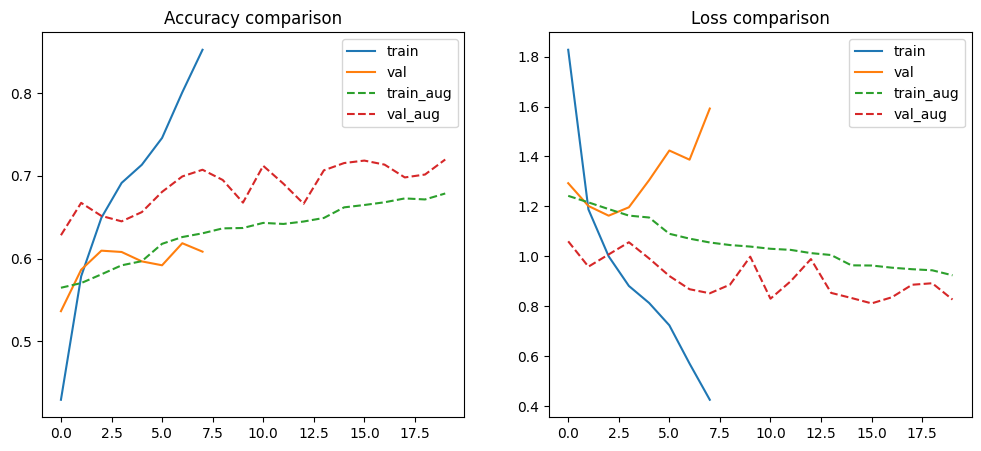

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.plot(history_aug.history["accuracy"], "--", label="train_aug")
plt.plot(history_aug.history["val_accuracy"], "--", label="val_aug")

plt.title("Accuracy comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")

plt.plot(history_aug.history["loss"], "--", label="train_aug")
plt.plot(history_aug.history["val_loss"], "--", label="val_aug")

plt.title("Loss comparison")
plt.legend()

plt.show()

### Tâche 4 : CNN Profond
1. Construisez un CNN plus profond :
   - Conv2D(32, 3x3) × 2 + MaxPooling
   - Conv2D(64, 3x3) × 2 + MaxPooling
   - Conv2D(128, 3x3) × 2 + MaxPooling
   - Flatten + Dense(256) + Dropout(0.5)
   - Dense(128) + Dropout(0.3)
   - Dense(10, softmax)
2. Utilisez Batch Normalization après chaque Conv2D
3. Entraînez avec data augmentation
4. Comparez avec le modèle simple

Attendus : CNN profond entraîné, métriques comparées

In [ ]:
def create_model_large() -> keras.Sequential:
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(32, 32, 3), name="input"),
            keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
            keras.layers.MaxPooling2D((2, 2), name="pool1"),
            keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
            keras.layers.MaxPooling2D((2, 2), name="pool2"),
            keras.layers.Conv2D(128, (3, 3), activation="relu", name="conv3"),
            keras.layers.MaxPooling2D((2, 2), name="pool3"),
            keras.layers.Flatten(name="flatten"),
            keras.layers.Dense(256, activation="relu", name="dense1"),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(128, activation="relu", name="dense2"),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(10, activation="softmax", name="output"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model_large = create_model_large()
model_large.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,762 (1010.79 KB)

 Trainable params: 258,762 (1010.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_aug_large = model_large.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.2486 - loss: 2.0552 - val_accuracy: 0.3564 - val_loss: 1.7023 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3313 - loss: 1.7970 - val_accuracy: 0.4134 - val_loss: 1.6373 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3770 - loss: 1.6976 - val_accuracy: 0.4223 - val_loss: 1.5738 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4105 - loss: 1.6249 - val_accuracy: 0.5025 - val_loss: 1.3724 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.4340 - loss: 1.5690 - val_accuracy: 0.5159 - val_loss: 1.3526 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4566 - loss: 1.5239 - val_accuracy: 0.4655 - val_loss: 1.4599 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 57ms/step - accuracy: 0.4697 - l

In [ ]:
test_loss_aug_large, test_accuracy_aug_large = model_large.evaluate(
    X_test_norm, y_test_onehot, verbose=1
)

print(f"\nTest loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

print(f"\nTest loss aug: {test_loss_aug}")
print(f"Test accuracy aug: {test_accuracy_aug}")

print(f"\nTest loss aug large: {test_loss_aug_large}")
print(f"Test accuracy aug large: {test_accuracy_aug_large}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6487 - loss: 0.9978

Test loss: 0.8376417756080627
Test accuracy: 0.7153000235557556

Test loss aug: 0.8376417756080627
Test accuracy aug: 0.7153000235557556

Test loss aug large: 0.9977837800979614
Test accuracy aug large: 0.6486999988555908


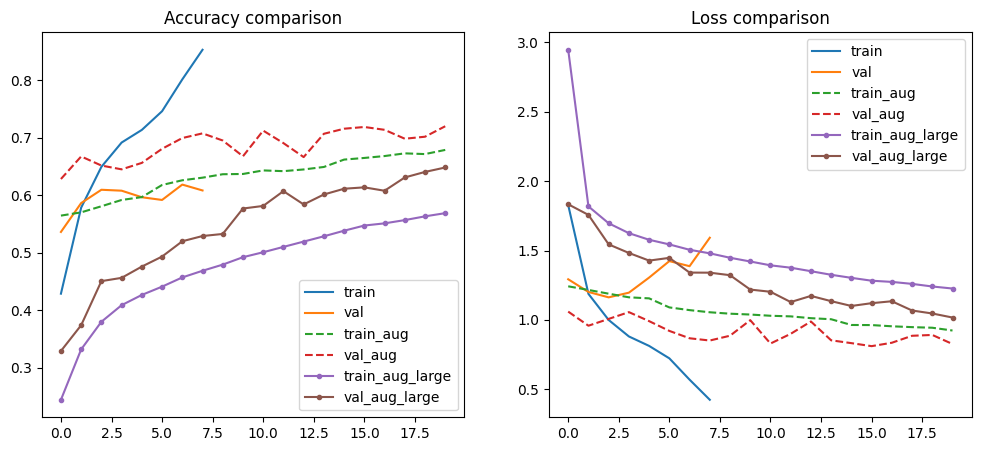

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.plot(history_aug.history["accuracy"], "--", label="train_aug")
plt.plot(history_aug.history["val_accuracy"], "--", label="val_aug")

plt.plot(history_aug_large.history["accuracy"], ".-", label="train_aug_large")
plt.plot(history_aug_large.history["val_accuracy"], ".-", label="val_aug_large")

plt.title("Accuracy comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")

plt.plot(history_aug.history["loss"], "--", label="train_aug")
plt.plot(history_aug.history["val_loss"], "--", label="val_aug")

plt.plot(history_aug_large.history["loss"], ".-", label="train_aug_large")
plt.plot(history_aug_large.history["val_loss"], ".-", label="val_aug_large")

plt.title("Loss comparison")
plt.legend()

plt.show()

### Tâche 5 : Évaluation Complète
1. Évaluez le meilleur modèle sur test set
2. Calculez accuracy, loss
3. Prédisez sur 20 images de test
4. Visualisez 10 prédictions (image + label + confiance)
5. Identifiez les erreurs (images mal classifiées)

Attendus : Évaluation précise, visualisations claires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


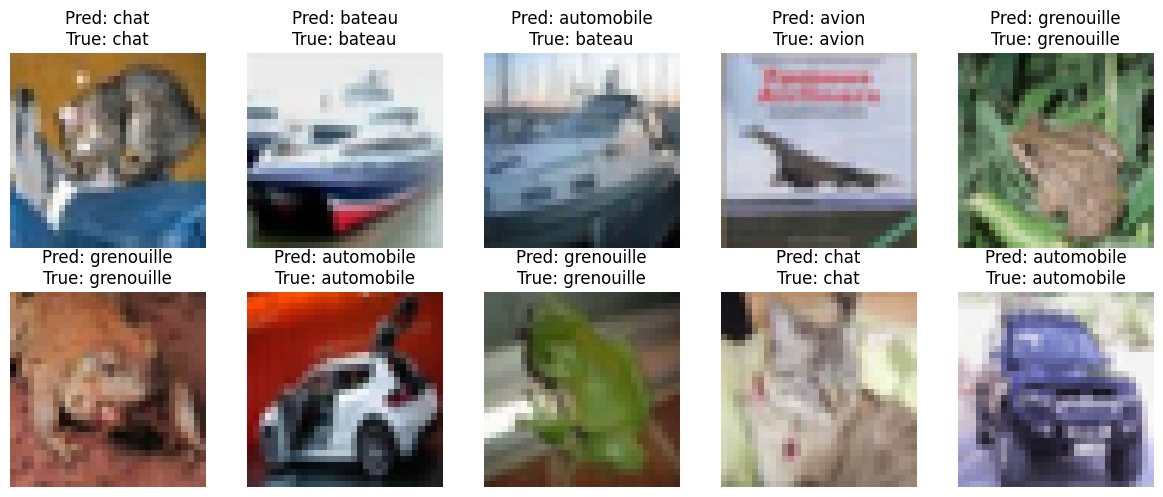

In [ ]:
predictions = model.predict(X_test_norm)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Pred: {labels[int(predicted_classes[i])]}\nTrue: {labels[int(y_test[i])]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
true_classes = np.argmax(y_test_onehot, axis=1)
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1000
           1       0.75      0.90      0.82      1000
           2       0.70      0.52      0.60      1000
           3       0.65      0.40      0.50      1000
           4       0.67      0.69      0.68      1000
           5       0.73      0.55      0.63      1000
           6       0.62      0.89      0.73      1000
           7       0.70      0.79      0.74      1000
           8       0.88      0.78      0.83      1000
           9       0.73      0.85      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



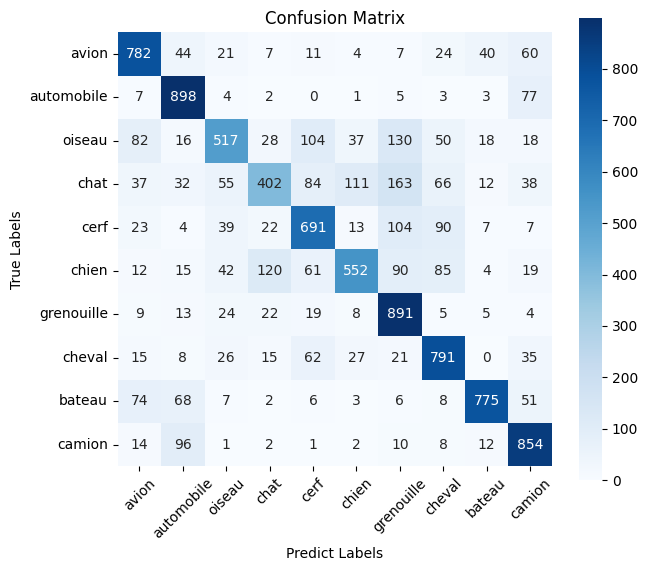

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True)
plt.xlabel("Predict Labels")
plt.xticks(np.arange(0.5, len(labels) + 0.5, 1), labels, rotation=45)
plt.ylabel("True Labels")
plt.yticks(np.arange(0.5, len(labels) + 0.5, 1), labels, rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
mask_mistakes = true_classes != predicted_classes
true_classes_mistakes = true_classes[mask_mistakes]
predicted_classes_mistakes = predicted_classes[mask_mistakes]
X_test_mistakes = X_test[mask_mistakes]

print("Nombre d'images mal classées:", len(X_test_mistakes))

Nombre d'images mal classées: 2847


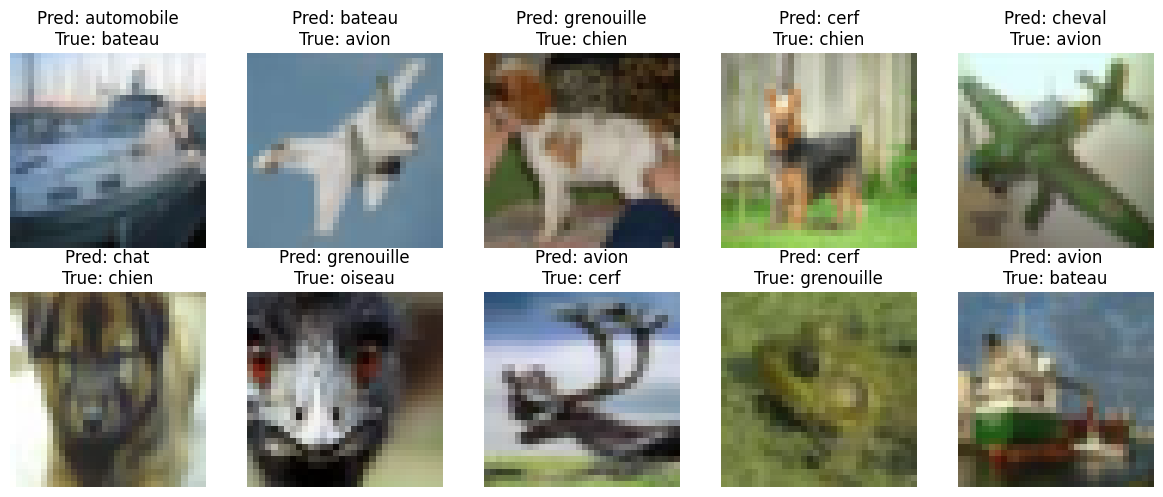

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_mistakes[i], cmap="gray")
    plt.title(
        f"Pred: {labels[int(predicted_classes_mistakes[i])]}\nTrue: {labels[int(true_classes_mistakes[i])]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Tâche 6 : Optimisation d'Hyperparamètres
1. Testez différentes configurations :
   - Learning rates : 0.001, 0.0005, 0.0001
   - Batch sizes : 16, 32, 64
   - Dropout : 0.2, 0.3, 0.5
2. Comparez les performances
3. Identifiez la meilleure configuration
4. Justifiez vos choix

Attendus : Tuning systématique, résultats documentés

In [ ]:
def create_model_hyperparameter_search(
    learning_rate: float, dropout_rate: float
) -> keras.Sequential:
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(32, 32, 3), name="input"),
            keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
            keras.layers.MaxPooling2D((2, 2), name="pool1"),
            keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
            keras.layers.MaxPooling2D((2, 2), name="pool2"),
            keras.layers.Flatten(name="flatten"),
            keras.layers.Dense(128, activation="relu", name="dense1"),
            keras.layers.Dropout(dropout_rate, name="dropout1"),
            keras.layers.Dense(10, activation="softmax", name="output"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def create_generators(X, y, batch_size, train_datagen, val_datagen):

    train_generator = train_datagen.flow(
        X,
        y,
        batch_size=batch_size,
        subset="training",
    )

    val_generator = val_datagen.flow(
        X,
        y,
        batch_size=batch_size,
        subset="validation",
    )

    return train_generator, val_generator


def train_model(model, train_generator, val_generator):

    history = model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator,
        callbacks=[create_reduce_lr(), create_early_stopping()],
        verbose=1,
    )

    return history


def hyperparameter_search(X_train, y_train, train_datagen, val_datagen):

    learning_rates = [0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]
    dropouts = [0.2, 0.3, 0.5]

    results = []

    for lr, batch, dropout in itertools.product(learning_rates, batch_sizes, dropouts):
        print(f"\nTraining | lr={lr} | batch={batch} | dropout={dropout}")

        model = create_model_hyperparameter_search(lr, dropout)

        train_gen, val_gen = create_generators(
            X_train,
            y_train,
            batch,
            train_datagen,
            val_datagen,
        )

        history = train_model(model, train_gen, val_gen)

        results.append(
            {
                "learning_rate": lr,
                "batch_size": batch,
                "dropout": dropout,
                "val_accuracy": max(history.history["val_accuracy"]),
            }
        )

    return pd.DataFrame(results)


results = hyperparameter_search(
    X_train_norm,
    y_train_onehot,
    train_datagen,
    val_datagen,
)

results.sort_values("val_accuracy", ascending=False).head()


Training | lr=0.001 | batch=16 | dropout=0.2
Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.2761 - loss: 2.0170 - val_accuracy: 0.3432 - val_loss: 1.7374 - learning_rate: 0.0010
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3483 - loss: 1.7759 - val_accuracy: 0.4159 - val_loss: 1.5775 - learning_rate: 0.0010
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3730 - loss: 1.7225 - val_accuracy: 0.4372 - val_loss: 1.5300 - learning_rate: 0.0010
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3832 - loss: 1.6902 - val_accuracy: 0.4754 - val_loss: 1.4529 - learning_rate: 0.0010
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3952 - loss: 1.6683 - val_accuracy: 0.4598 - val_loss: 1.4820 - learning_rate: 0.0010
Epoch 6/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.4029 - loss: 1.6508 - val_accuracy: 0.4104 - val_loss: 1.6766 - learning_rate: 0.0010
Epoch 7/20
2493/2500 ━━━

,learning_rate,batch_size,dropout,val_accuracy
12,0.0005,32,0.2,0.6498
15,0.0005,64,0.2,0.6495
3,0.0010,32,0.2,0.6439
10,0.0005,16,0.3,0.6408
9,0.0005,16,0.2,0.6388


In [ ]:
best_config = results.loc[results["val_accuracy"].idxmax()]

print("Best configuration:")
print(best_config)

Best configuration:
learning_rate     0.0005
batch_size       32.0000
dropout           0.2000
val_accuracy      0.6498
Name: 12, dtype: float64


### Tâche 7 : Transfer Learning (Bonus)
1. Chargez un modèle pré-entraîné (MobileNetV2)
2. Gellez les premières couches (freeze)
3. Ajoutez des couches fully-connected pour CIFAR-10
4. Fine-tune sur CIFAR-10
5. Comparez avec CNN depuis zéro

Attendus : Transfer learning implémenté, performance améliorée

In [ ]:
# ===
# MobileNetV2
# ===

IMG_SIZE = 96

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(10, activation="softmax")(x)

model_tl = keras.Model(inputs=base_model.input, outputs=outputs)

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


def resize_images(X):
    return tf.image.resize(X, (IMG_SIZE, IMG_SIZE))


X_train_resized = resize_images(X_train_norm)
X_test_resized = resize_images(X_test_norm)

train_gen_tl, val_gen_tl = create_generators(
    X_train_resized,
    y_train_onehot,
    64,
    train_datagen,
    val_datagen,
)

history_tl = model_tl.fit(
    train_gen_tl,
    epochs=10,
    validation_data=val_gen_tl,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

# ===
# Fine-Tunning
# ===

for layer in base_model.layers[-30:]:
    layer.trainable = True

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model_tl.fit(
    train_gen_tl,
    epochs=10,
    batch_size=64,
    validation_data=val_gen_tl,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 288ms/step - accuracy: 0.6002 - loss: 1.1821 - val_accuracy: 0.7596 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 326ms/step - accuracy: 0.6599 - loss: 0.9784 - val_accuracy: 0.7718 - val_loss: 0.6686 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 260s 323ms/step - accuracy: 0.6779 - loss: 0.9288 - val_accuracy: 0.7751 - val_loss: 0.6587 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 322ms/step - accuracy: 0.6844 - loss: 0.9094 - val_accuracy: 0.7765 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 325ms/step - accuracy: 0.6880 - loss: 0.8930 - val_accuracy: 0.7787 - val_loss: 0.6331 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 324ms/step - accuracy: 0.6902 - loss: 0.8800 - val_accuracy: 0.7778 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 7/10
625/

In [ ]:
test_loss_ft, test_accuracy_ft = model_tl.evaluate(
    X_test_resized, y_test_onehot, verbose=1
)

print(f"\nTest loss ft: {test_loss_ft}")
print(f"Test accuracy ft: {test_accuracy_ft}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8275 - loss: 0.5087
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8275 - loss: 0.5087

Test loss: 0.5087183713912964
Test accuracy: 0.8274999856948853

Test loss aug: 0.5087183713912964
Test accuracy aug: 0.8274999856948853
